1.) Data ingestion

2.)Data Cleaning

3.)Data Visualization (minimum 10 visualization with insights)

4.)feature selection

5.)seperating the num_cols,cat_cols,text_cols

6.)ColumnTransformer

7.)Pipeline

8.)Train Test Split

9.)Model Fitting

10.)Model Prediction

11.)Model Evalution (train_score, test_score , val_score)

1)Data Ingestion

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("employee_promotion_filtered_v.csv")
df

,promoted,education_level,department,years_at_company,years_in_current_role,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,...,marital_status,city_tier,mentoring_sessions,certifications_count,gender,skill_assessment_score,employment_type,age,training_hours_last_year,performance_last_year
0,0,Master,Finance,10,4,137633.720337,7.587737,16743.979863,7532.711623,0.930558,...,Married,Tier1,3,2,Female,67.560751,Full-time,50,25.361303,100.000000
1,0,Bachelor,Sales,9,5,114499.406460,10.372718,9074.413744,7694.310517,0.962302,...,Married,Tier1,2,4,Male,74.851443,Full-time,36,43.760654,78.270415
2,0,Bachelor,Engineering,7,5,124233.224752,10.115308,11807.910102,6380.645687,0.891287,...,Married,Tier2,4,2,Female,44.964704,Full-time,29,25.275693,72.824611
3,0,Bachelor,Operations,4,4,100896.326509,9.800044,8496.840118,7046.402195,1.000000,...,Married,Tier1,2,1,Male,50.993617,Full-time,42,33.507680,54.280668
4,0,Master,Operations,2,2,93054.051809,7.501102,15099.354711,4557.907600,0.896275,...,Married,Tier1,2,7,Female,78.227838,Full-time,40,44.730269,86.075898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,0,Bachelor,HR,6,4,105125.063303,2.987237,8503.492849,4779.749819,0.981053,...,Married,Tier2,4,1,Female,50.224609,Full-time,48,45.745451,45.077191
5996,0,Bachelor,Operations,4,3,96692.589781,10.660167,11799.090104,6069.545518,0.938542,...,Single,Tier2,0,3,Male,72.092820,Full-time,31,27.919124,90.199233
5997,0,Master,Engineering,3,0,79334.657512,5.562509,11772.787018,6492.755067,0.966895,...,Single,Tier2,2,1,Male,66.718900,Full-time,53,64.907449,81.336037
5998,0,Bachelor,Sales,11,9,135243.636810,7.304890,10649.776454,5000.982159,0.935966,...,Married,Tier1,1,1,Female,76.211849,Full-time,47,40.410619,71.254882


In [2]:
df.isnull().sum()


promoted                     0
education_level              0
department                   0
years_at_company             0
years_in_current_role        0
salary                       0
salary_increase_percent      0
bonus_last_year              0
stock_options                0
attendance_rate              0
employee_engagement_score    0
job_satisfaction_score       0
internal_mobility_score      0
marital_status               0
city_tier                    0
mentoring_sessions           0
certifications_count         0
gender                       0
skill_assessment_score       0
employment_type              0
age                          0
training_hours_last_year     0
performance_last_year        0
dtype: int64

In [3]:
df.columns

Index(['promoted', 'education_level', 'department', 'years_at_company',
       'years_in_current_role', 'salary', 'salary_increase_percent',
       'bonus_last_year', 'stock_options', 'attendance_rate',
       'employee_engagement_score', 'job_satisfaction_score',
       'internal_mobility_score', 'marital_status', 'city_tier',
       'mentoring_sessions', 'certifications_count', 'gender',
       'skill_assessment_score', 'employment_type', 'age',
       'training_hours_last_year', 'performance_last_year'],
      dtype='str')

In [4]:
# df = df.drop(columns=['marital_status','city_tier','mentoring_sessions','certifications_count'])


Visualization

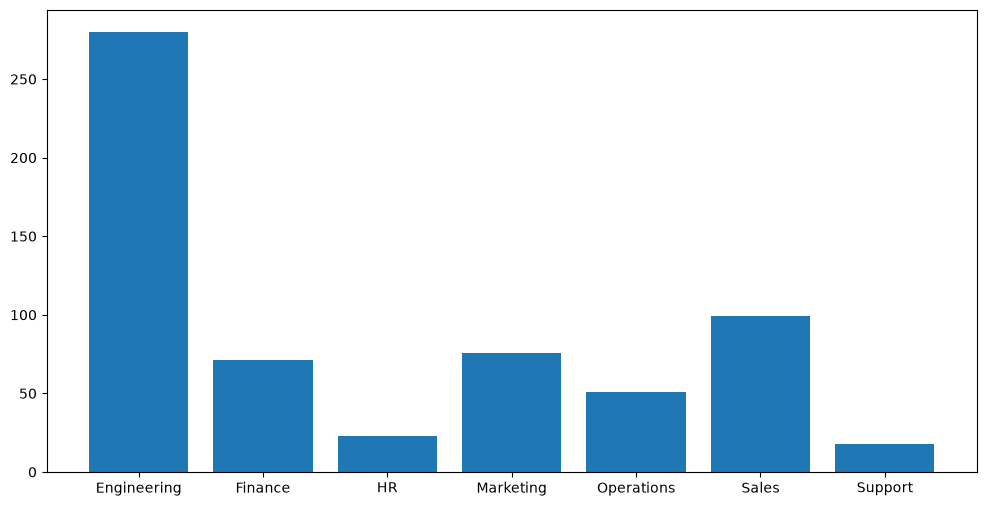

In [5]:
df1 = df.groupby("department")["promoted"].aggregate(sum)
df1 = df1.reset_index()


import matplotlib.pyplot as plt
import seaborn as sns


x = df1["department"]
y = df1["promoted"]

plt.figure(figsize=(12,6))
plt.bar(x,y)

plt.show()


In [6]:
df1.columns

Index(['department', 'promoted'], dtype='str')

<function matplotlib.pyplot.show(close=None, block=None)>

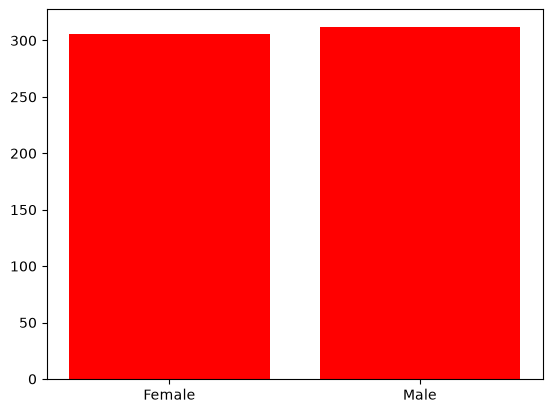

In [7]:
df2 = df.groupby("gender")["promoted"].aggregate(sum)
df2 = df2.reset_index()

x = df2["gender"]
y = df2["promoted"]

plt.bar(x,y,color="red")
plt.show

In [8]:
df2.columns

Index(['gender', 'promoted'], dtype='str')

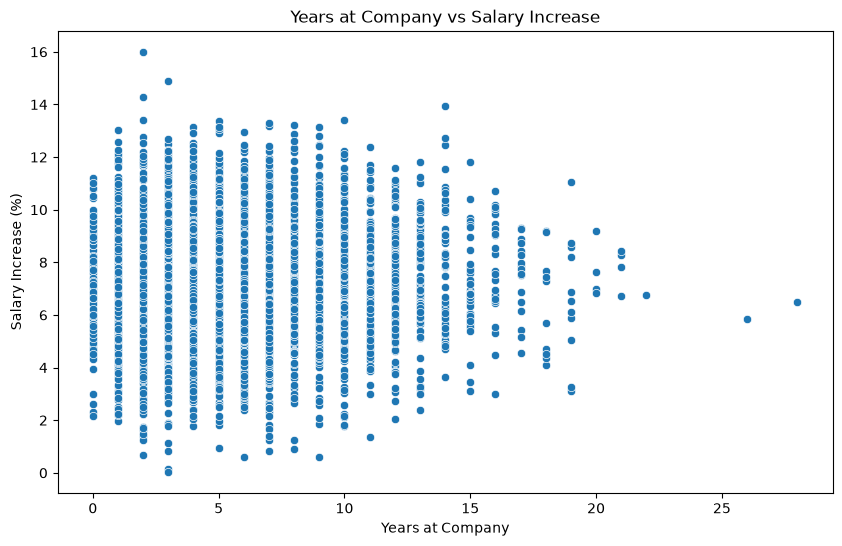

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='years_at_company',
    y='salary_increase_percent'
)

plt.title('Years at Company vs Salary Increase')
plt.xlabel('Years at Company')
plt.ylabel('Salary Increase (%)')

plt.show()

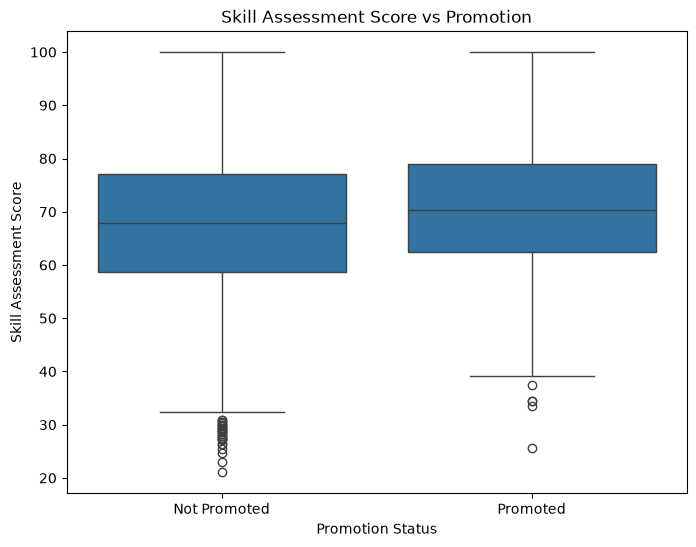

In [10]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='promoted',
    y='skill_assessment_score'
)

plt.title('Skill Assessment Score vs Promotion')
plt.xlabel('Promotion Status')
plt.ylabel('Skill Assessment Score')
plt.xticks([0, 1], ['Not Promoted', 'Promoted'])

plt.show()

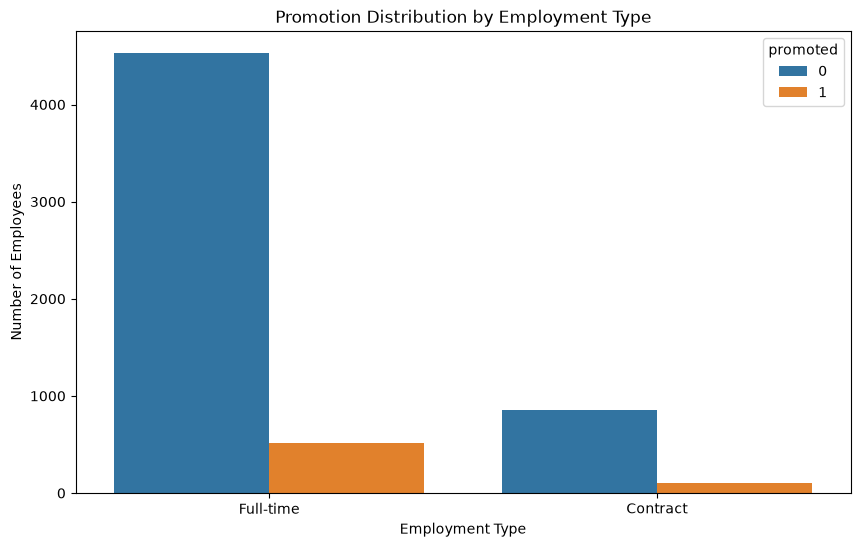

In [11]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='employment_type',
    hue='promoted'
)

plt.title('Promotion Distribution by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Number of Employees')

plt.show()

In [12]:
df.columns

Index(['promoted', 'education_level', 'department', 'years_at_company',
       'years_in_current_role', 'salary', 'salary_increase_percent',
       'bonus_last_year', 'stock_options', 'attendance_rate',
       'employee_engagement_score', 'job_satisfaction_score',
       'internal_mobility_score', 'marital_status', 'city_tier',
       'mentoring_sessions', 'certifications_count', 'gender',
       'skill_assessment_score', 'employment_type', 'age',
       'training_hours_last_year', 'performance_last_year'],
      dtype='str')

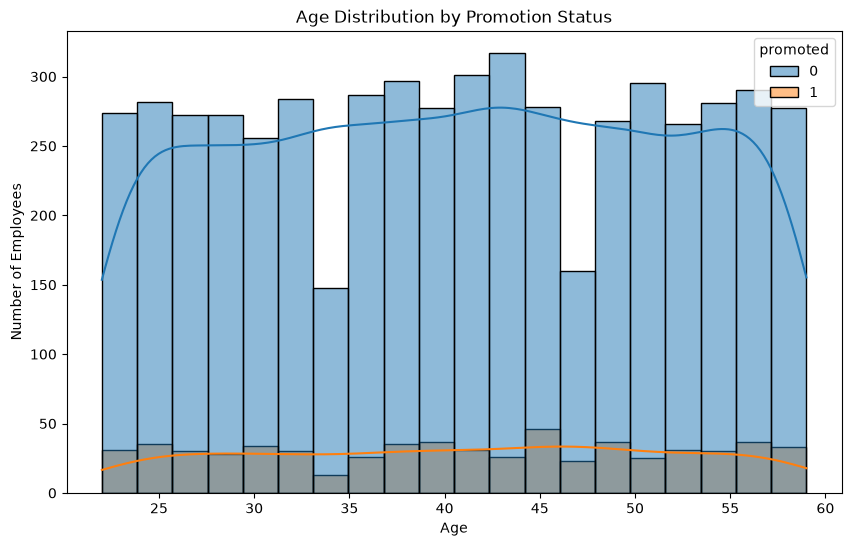

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='age',
    hue='promoted',
    kde=True,
    bins=20
)

plt.title('Age Distribution by Promotion Status')
plt.xlabel('Age')
plt.ylabel('Number of Employees')

plt.show()

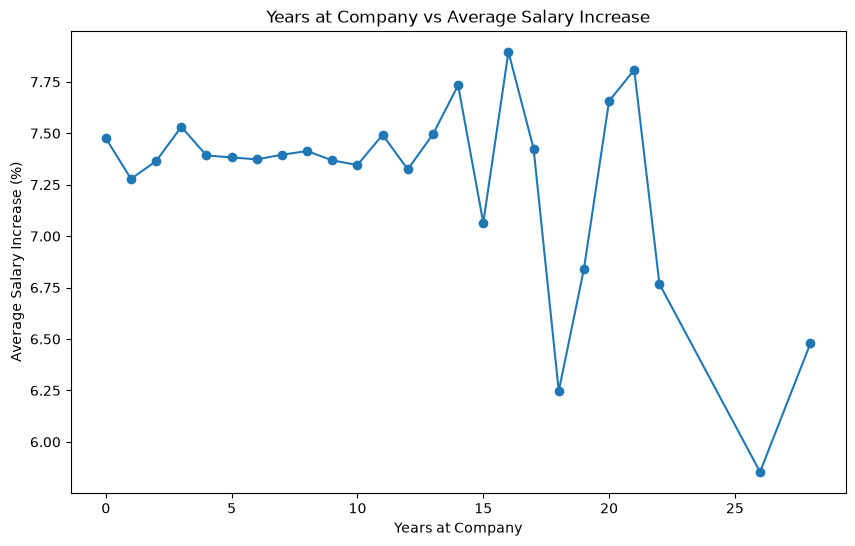

In [14]:


df6 = df.groupby('years_at_company')['salary_increase_percent'].mean()
df6 = df6.reset_index()

x = df6["years_at_company"]
y = df6["salary_increase_percent"]

plt.figure(figsize=(10, 6))

plt.plot(x,y, marker='o')
plt.title('Years at Company vs Average Salary Increase')
plt.xlabel('Years at Company')
plt.ylabel('Average Salary Increase (%)')


plt.show()

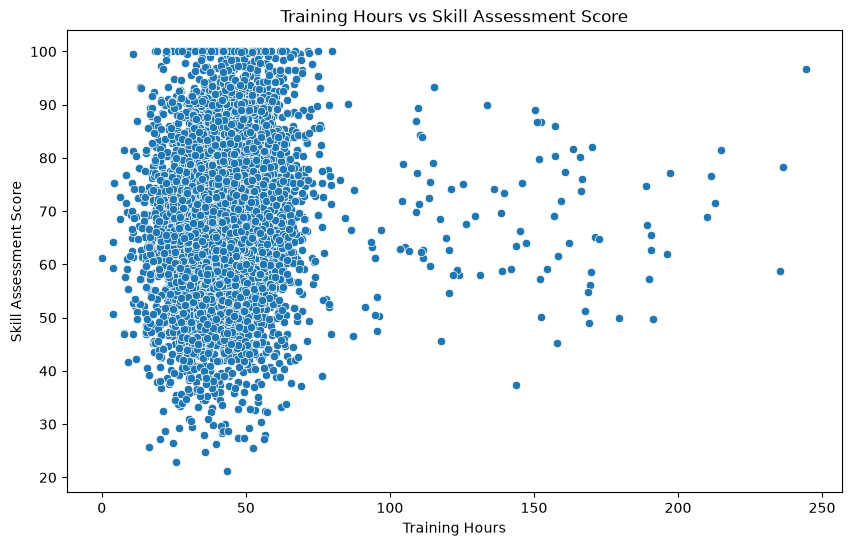

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='training_hours_last_year',
    y='skill_assessment_score'
)

plt.title('Training Hours vs Skill Assessment Score')
plt.xlabel('Training Hours')
plt.ylabel('Skill Assessment Score')

plt.show()

In [16]:
# df1 = df.groupby('performance_last_year')['kpi_achievement_percent'].mean().reset_index()

# plt.figure(figsize=(10, 6))

# sns.lineplot(
#     data=df1,
#     x='performance_last_year',
#     y='kpi_achievement_percent',
#     marker='o'
# )

# plt.title('Performance vs Average KPI Achievement')
# plt.xlabel('Performance Last Year')
# plt.ylabel('Average KPI Achievement (%)')

# plt.show()

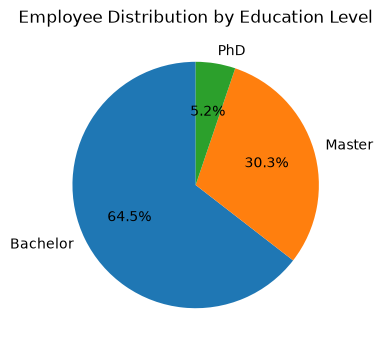

In [17]:
data = df['education_level'].value_counts()

plt.figure(figsize=(4, 4))

plt.pie(
    data.values,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Employee Distribution by Education Level')
plt.show()

feature selection

In [18]:
df

,promoted,education_level,department,years_at_company,years_in_current_role,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,...,marital_status,city_tier,mentoring_sessions,certifications_count,gender,skill_assessment_score,employment_type,age,training_hours_last_year,performance_last_year
0,0,Master,Finance,10,4,137633.720337,7.587737,16743.979863,7532.711623,0.930558,...,Married,Tier1,3,2,Female,67.560751,Full-time,50,25.361303,100.000000
1,0,Bachelor,Sales,9,5,114499.406460,10.372718,9074.413744,7694.310517,0.962302,...,Married,Tier1,2,4,Male,74.851443,Full-time,36,43.760654,78.270415
2,0,Bachelor,Engineering,7,5,124233.224752,10.115308,11807.910102,6380.645687,0.891287,...,Married,Tier2,4,2,Female,44.964704,Full-time,29,25.275693,72.824611
3,0,Bachelor,Operations,4,4,100896.326509,9.800044,8496.840118,7046.402195,1.000000,...,Married,Tier1,2,1,Male,50.993617,Full-time,42,33.507680,54.280668
4,0,Master,Operations,2,2,93054.051809,7.501102,15099.354711,4557.907600,0.896275,...,Married,Tier1,2,7,Female,78.227838,Full-time,40,44.730269,86.075898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,0,Bachelor,HR,6,4,105125.063303,2.987237,8503.492849,4779.749819,0.981053,...,Married,Tier2,4,1,Female,50.224609,Full-time,48,45.745451,45.077191
5996,0,Bachelor,Operations,4,3,96692.589781,10.660167,11799.090104,6069.545518,0.938542,...,Single,Tier2,0,3,Male,72.092820,Full-time,31,27.919124,90.199233
5997,0,Master,Engineering,3,0,79334.657512,5.562509,11772.787018,6492.755067,0.966895,...,Single,Tier2,2,1,Male,66.718900,Full-time,53,64.907449,81.336037
5998,0,Bachelor,Sales,11,9,135243.636810,7.304890,10649.776454,5000.982159,0.935966,...,Married,Tier1,1,1,Female,76.211849,Full-time,47,40.410619,71.254882


In [19]:
y = df['promoted']
X = df[['education_level','department','years_at_company','years_in_current_role','salary',
      'salary_increase_percent','bonus_last_year','stock_options','attendance_rate',
      'employee_engagement_score','job_satisfaction_score','internal_mobility_score']]



In [20]:
num_cols = ['years_at_company','years_in_current_role','salary',
            'salary_increase_percent','bonus_last_year',
            'stock_options','attendance_rate','employee_engagement_score',
            'job_satisfaction_score','internal_mobility_score']
cat_cols = ['education_level','department']



In [21]:
df.isnull().sum()

promoted                     0
education_level              0
department                   0
years_at_company             0
years_in_current_role        0
salary                       0
salary_increase_percent      0
bonus_last_year              0
stock_options                0
attendance_rate              0
employee_engagement_score    0
job_satisfaction_score       0
internal_mobility_score      0
marital_status               0
city_tier                    0
mentoring_sessions           0
certifications_count         0
gender                       0
skill_assessment_score       0
employment_type              0
age                          0
training_hours_last_year     0
performance_last_year        0
dtype: int64

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num",MinMaxScaler(),num_cols),
        ("cat",OneHotEncoder(),cat_cols),
    ]
)

7) pipeline

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


model = Pipeline(
    steps = [
        ("preprocessing",preprocessor),
        ("regression",RandomForestClassifier())
    ]
)


<!-- 8)train test split -->

In [24]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [25]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['years_at_company',
                                                   'years_in_current_role',
                                                   'salary',
                                                   'salary_increase_percent',
                                                   'bonus_last_year',
                                                   'stock_options',
                                                   'attendance_rate',
                                                   'employee_engagement_score',
                                                   'job_satisfaction_score',
                                                   'internal_mobility_score']),
                                                 ('cat', OneHotEncoder(),
                                                  ['education_level',
                                                   'department'])])),
                ('regression', RandomForestClassifier())])

In [26]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1200,))

In [27]:
print(model.score(X_train,y_train))
print(model.score(X_test,y_test))

1.0
0.8941666666666667


In [28]:
!pip show scikit-learn


Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

In [29]:
import joblib
joblib.dump(model,'emp_promotion_pred.joblib')

['emp_promotion_pred.joblib']